# Lab 2: Cameron Mangione (Classification setup for Lab 3)

## 1. State the question

Which classification/categorical factors have the greatest influence on salary in usd for data science positions?

## 2. Identify the response and relevant predictors

Salary in USD is the response variable, while the relavent predictor variables include experience level, employment type, job_title, salry currency, employee residence, remote ratio, company location, company size and employee residence.

## 3. Related data preparation

In terms of data preparation, we'll need to create a train and test split of the categorical variables, and convert salary_in_usd to a categoricial variable to work in the classifier model. Since all of our response variables are categorical and non-binary, we will need to apply One Hot Encoding.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.pyplot import subplots
from matplotlib import cm
from ISLP import load_data, confusion_table
from ISLP.models import (ModelSpec as MS,summarize,poly)
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree, DecisionTreeRegressor
from sklearn.preprocessing import OneHotEncoder, LabelBinarizer
from sklearn.metrics import (accuracy_score,
                             log_loss, mean_squared_error)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay
from statsmodels.stats.anova import anova_lm
import statsmodels.formula.api as smf
import statsmodels.api as sm
from ISLP.models import Stepwise, sklearn_selected
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from functools import partial
import sklearn.linear_model as skl
import sklearn.model_selection as skm
from ISLP import load_data
from sklearn.preprocessing import StandardScaler
from statsmodels.api import OLS
from ISLP.models import contrast
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import GradientBoostingClassifier
from catboost import CatBoostClassifier

In [2]:
#Import the dataset
df = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")

For our categorization of US Salary, we chose the bins of 0-90k, 90,180k, and 180k-600k(upper-limit of our dataset).

0-90k represents around the minimum to average salary of a data analyst, 90-180k includes the mean of our dataset (approx. 130k), and then the rest of our data goes to the upper limit of our dataset which is $600k usd.

In [3]:
# Create 3 categories for salaries - Low, Medium, High
df['salary_in_usd'] = pd.cut(df['salary_in_usd'],
                                      bins=[0, 90000, 180000, 600000],
                                      labels=['Low', 'Medium', 'High'])

We used one-hot encoding for all of our variables since we are not using any binary variables in our dataset. 

Our train-test-split is based on the years 2020-2022 comprising the first 2,035 points in our data, and the rest comprising our 2023 data.

In [4]:
# One-hot encode categorical variables
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_cols = ['remote_ratio', 'company_location', 'employee_residence','experience_level','employment_type','job_title','salary_currency','company_size']
encoded_col = pd.DataFrame(encoder.fit_transform(df[categorical_cols]).toarray())
encoded_col.columns = encoder.get_feature_names_out(categorical_cols)

# Split the Data between test and train
X_train, X_test, y_train, y_test =  train_test_split(encoded_col,
                                                 df['salary_in_usd'],
                                                 train_size = 2035, test_size = 1156,
                                                 random_state = 2)

# reset the index of the salaries DataFrame
df = df.reset_index(drop=True)

## 4. Apply the bagging, random forest, and boosting approach learned in class

Bagging

For each of these methods we attempted to use the default settings to compare them directly, but also adjusted the settings when different circumstances were needed.

In [5]:
# fit Bagging model
df_bagging = RandomForestClassifier(max_features=X_train.shape[1], random_state = 2)
df_bagging.fit(X_train,y_train)

print("Number of trees:", df_bagging.n_estimators)
print("Number of features tried at each split:",df_bagging.max_features)
print("Training score: {:.2f}%".format(df_bagging.score(X_train,y_train)*100))
print("Test accuracy: {:.2f}%".format(df_bagging.score(X_test, y_test) * 100))

Number of trees: 100
Number of features tried at each split: 280
Training score: 76.71%
Test accuracy: 68.86%


Our bagging model used 280 splits since those were the number of features that we had when we split all of our features into individual categories.

Our model performed quite well in training, and performed relatively well in testing here. We see a 7-9% dip between testing and training but both of them being above 66% percent is still successful overall.

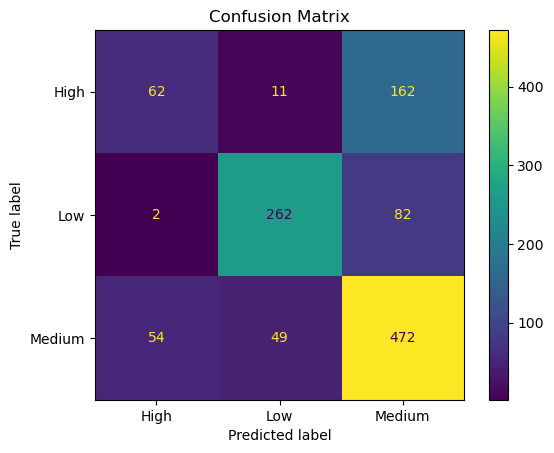

In [6]:
# Predict values
y_pred_bag = df_bagging.predict(X_test)

# plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_bag)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=df_bagging.classes_)
display.plot()
plt.title('Confusion Matrix')
plt.show()

This model had the most total errors in the medium, but the lowest proportional accuracy was in the high group (approx. 61.64%).

In [7]:
# create a dataframe of feature importances and their corresponding column names
importances_df_bagging = pd.DataFrame({'Feature': X_train.columns, 'Importance': df_bagging.feature_importances_})
importances_df_bagging = importances_df_bagging.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_bagging)

                    Feature  Importance
0     employee_residence_US    0.316660
1       experience_level_EN    0.042835
2    job_title_Data Analyst    0.040990
3       experience_level_SE    0.034312
4       experience_level_MI    0.029215
..                      ...         ...
275     company_location_BE    0.000000
276     salary_currency_THB    0.000000
277     salary_currency_SGD    0.000000
278     company_location_AR    0.000000
279     company_location_AS    0.000000

[280 rows x 2 columns]


For bagging, US residence was by far the most important indicator, with the data analyst and entry level groups showing some overall importance as well.

Based on the importances here, some salary currencies and company locations were not important factors in this model.

For our second bagging model, we tuned the estimator parameter to produce a lower number of trees to see how that impacted our results.

Number of trees: 25
Number of features tried at each split: 280
Training score: 76.61%
Test accuracy: 68.60%


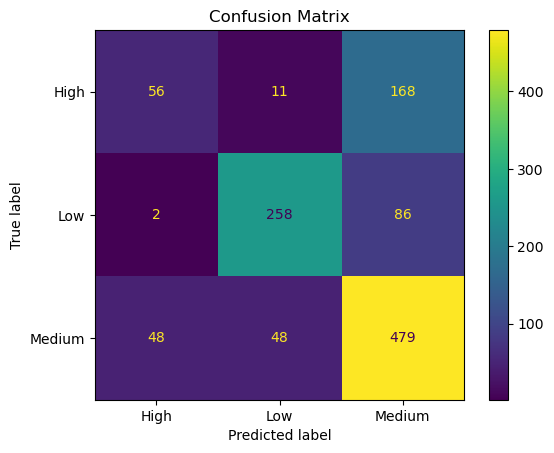

In [8]:
# fit Random Forests model (Fewer Estimators)
bagging2 = RandomForestClassifier(max_features=X_train.shape[1]
                                       ,random_state = 2
                                       ,n_estimators=25)

bagging2.fit(X_train,y_train)

# Predict values
y_pred_bag = bagging2.predict(X_test)


print("Number of trees:", bagging2.n_estimators)
print("Number of features tried at each split:",bagging2.max_features)
print("Training score: {:.2f}%".format(bagging2.score(X_train,y_train)*100))
print("Test accuracy: {:.2f}%".format(bagging2.score(X_test, y_test) * 100))
# plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_bag)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=bagging2.classes_)
display.plot()
plt.title('Confusion Matrix')
plt.show()

The number of estimators being lower did not have a major impact on our model. Our training score dropped by 0.1% and our test score went up but only by 0.34%.

This model also had the most total errors in the medium, and also had the lowest proportional accuracy was in the high group (approx. 62.32%).

In [9]:
# create a dataframe of feature importances and their corresponding column names
importances_df_bag = pd.DataFrame({'Feature': X_train.columns, 'Importance': bagging2.feature_importances_})
importances_df_bag = importances_df_bag.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_bag)

                    Feature  Importance
0     employee_residence_US    0.322805
1       experience_level_EN    0.043458
2    job_title_Data Analyst    0.040740
3       experience_level_SE    0.033089
4       experience_level_MI    0.029797
..                      ...         ...
275     salary_currency_PLN    0.000000
276     salary_currency_THB    0.000000
277     company_location_AS    0.000000
278     company_location_AR    0.000000
279     company_location_AM    0.000000

[280 rows x 2 columns]


The new bagging model also had US residence as by far the most important indicator, with the data analyst showing some overall importance as well, but entry level falling near or below 4%.

This new model also showed some salary currencies and company locations were not important factors in this model.

Overall, bagging performed quite well, and the tuning of the estimator parameter did not impact the model in a major way.

Random Forest

For our random forest model, we kept most of the settings as defaults, but did set the max features to be two for a reduced model compared to bagging.

Number of trees: 100
Number of features tried at each split: 2
Training score: 76.71%
Test accuracy: 68.77%


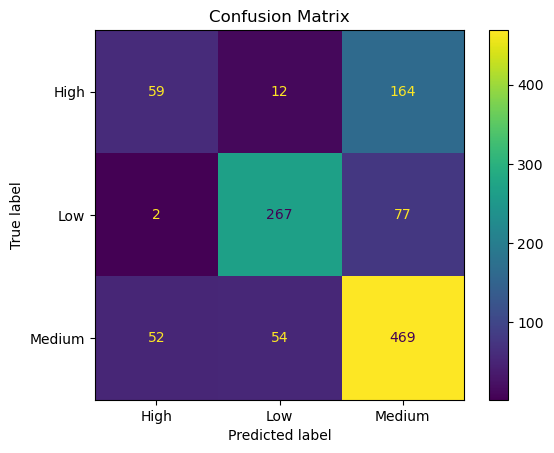

In [10]:
# fit Random Forests model
df_rf = RandomForestClassifier(max_features=2
                                       ,random_state = 2)

df_rf.fit(X_train,y_train)

# Predict values
y_pred_rf = df_rf.predict(X_test)

print("Number of trees:", df_rf.n_estimators)
print("Number of features tried at each split:",df_rf.max_features)
print("Training score: {:.2f}%".format(df_rf.score(X_train,y_train)*100))
print("Test accuracy: {:.2f}%".format(df_rf.score(X_test, y_test) * 100))

# plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_rf)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=df_rf.classes_)
display.plot()
plt.title('Confusion Matrix')
plt.show()

The random forest model had very similar or equal training and testing scores to bagging. Our random forest model in that regard performed fairly well in this regard.

THe random forest model was about 1-2% better in predicting medium, was very good at predicting low, and saw around a 15% reduction in predicting high (falling below 50% accuracy).

In [11]:
# create a dataframe of feature importances and their corresponding column names
importances_df_rf = pd.DataFrame({'Feature': X_train.columns, 'Importance': df_rf.feature_importances_})
importances_df_rf = importances_df_rf.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_df_rf)

                              Feature  Importance
0                 experience_level_SE    0.066429
1               employee_residence_US    0.065467
2                 company_location_US    0.058503
3                 salary_currency_USD    0.050499
4                 experience_level_EN    0.044979
..                                ...         ...
275             employee_residence_CN    0.000000
276             employee_residence_DZ    0.000000
277               company_location_MY    0.000000
278  job_title_Data Science Tech Lead    0.000000
279               salary_currency_HKD    0.000000

[280 rows x 2 columns]


While random forest also identified senior level and US residence as the most improtant factors, US residence was more in the 5-6% range here compared to 28-32% in bagging.

The Data Science Tech Lead role was identified as a non-important feature here as well.

Boosting

We used mostly default settings for the gradient boosting classifier, but tuned the learning rate in a later model.

In [12]:
# fit Gradient Boosting model
boost_df = GradientBoostingClassifier(max_depth=2
                                         , random_state=2)
boost_df.fit(X_train, y_train)

# create a dataframe of feature importances and their corresponding column names
importances_boost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': boost_df.feature_importances_})
importances_boost_df = importances_boost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_boost_df)

                                Feature  Importance
0                 employee_residence_US    0.458118
1                   experience_level_SE    0.100880
2                   experience_level_EN    0.060419
3                   experience_level_EX    0.051618
4                   salary_currency_USD    0.051581
..                                  ...         ...
275                 salary_currency_TRY    0.000000
276      job_title_Staff Data Scientist    0.000000
277                 company_location_MY    0.000000
278  job_title_Head of Machine Learning    0.000000
279                 company_location_DE    0.000000

[280 rows x 2 columns]


Boosting had the highest importance levels in this model for US residence and senior experience level, with some additional job titles such as staff data scientist and head of machine learning as non-important facotrs in the model.

Number of trees: 100
Number of features tried at each split: None
Training score: 70.07%
Test accuracy: 67.13%


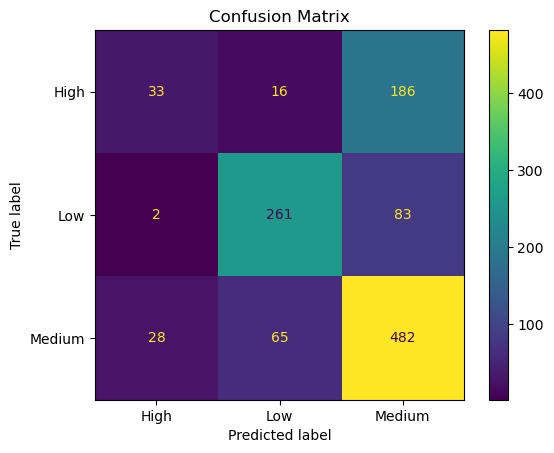

In [13]:
# Predict test
y_pred_boost = boost_df.predict(X_test)

print("Number of trees:", boost_df.n_estimators)
print("Number of features tried at each split:",boost_df.max_features)
print("Training score: {:.2f}%".format(boost_df.score(X_train,y_train)*100))
print("Test accuracy: {:.2f}%".format(boost_df.score(X_test, y_test) * 100))

# plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_boost)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=boost_df.classes_)
display.plot()
plt.title('Confusion Matrix')
plt.show()

Boosting does not use splits, and posted a lower training score compared to random forests and bagging. However, it posted an approximate equivalent testing score.

Predictions for boosting were very similar to random forests with low being the best, and high scoring the worst in predictions.

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\inspection\_plot\partial_dependence.py:990: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set_ylim([min_val, max_val])


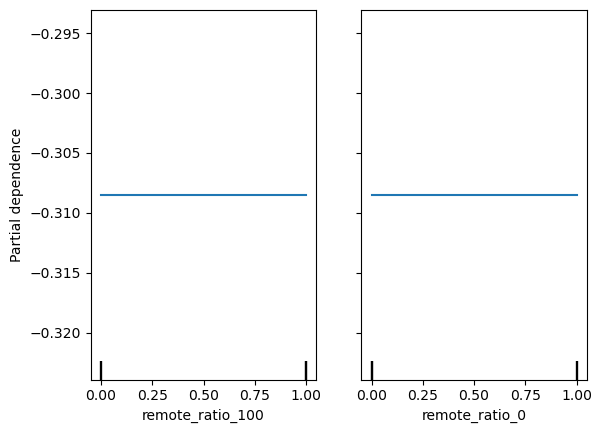

In [14]:
PartialDependenceDisplay.from_estimator(boost_df, X_train, ['remote_ratio_100', 'remote_ratio_0'], target="Low");

Our partial dependence plots did not show a significant impact over our feature space and the results.

Boosting with a Learning Rate

For this section, we tuned the paramter of learning rate to 0.2 while keeping the other factors the same as our previous model to see how it impacted our results.

Number of trees: 100
Number of features tried at each split: None
Training score: 72.04%
Test accuracy: 67.21%


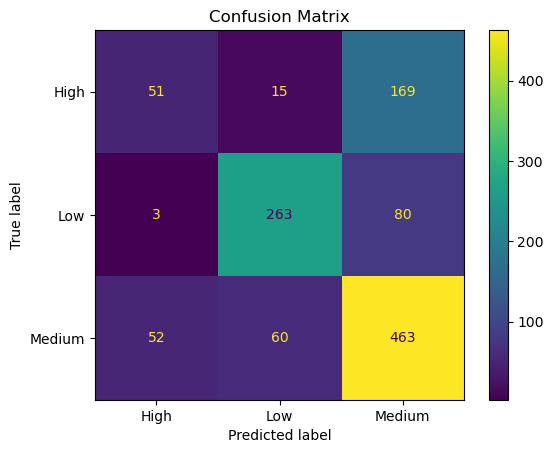

In [15]:
# fit the Gradient Boosting model with learning rate
gboost_df = GradientBoostingClassifier(max_depth=2
                                         , random_state=2
                                         , learning_rate=0.2)

gboost_df.fit(X_train, y_train)

# Predict test
y_pred_gboost = gboost_df.predict(X_test)

print("Number of trees:", gboost_df.n_estimators)
print("Number of features tried at each split:",gboost_df.max_features)
print("Training score: {:.2f}%".format(gboost_df.score(X_train,y_train)*100))
print("Test accuracy: {:.2f}%".format(gboost_df.score(X_test, y_test) * 100))

# plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_gboost)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=gboost_df.classes_)
display.plot()
plt.title('Confusion Matrix')
plt.show()

Overall, we see a ~1-2% training score increase, and around the same test score overall. 

We also see similar results in our confusion matrix here.

In [16]:
# create a dataframe of feature importances and their corresponding column names
importances_gboost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': gboost_df.feature_importances_})
importances_gboost_df = importances_gboost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_gboost_df)

                   Feature  Importance
0    employee_residence_US    0.428007
1      experience_level_SE    0.095195
2      experience_level_EN    0.056221
3      salary_currency_USD    0.049433
4      experience_level_EX    0.049070
..                     ...         ...
275    salary_currency_TRY    0.000000
276    company_location_AU    0.000000
277    company_location_AS    0.000000
278    company_location_AR    0.000000
279    company_location_AM    0.000000

[280 rows x 2 columns]


Our learning rate boost method produces slightly lower importances on US residence and senior experience level compared to our default boosting model.

## 5. Learn a new boosting method and apply it to your question. (XGBOOST + CATBOOST)

We used catboost in a similar way to our previous models with 100 iterations, a dpeth of 2, and a learning rate of 0.2. 

Verbose being equal to 10 means we see 10 results rather than 100, which helps for readability, but does not impact our computation here.

0:	learn: 1.0208884	total: 143ms	remaining: 14.1s
10:	learn: 0.8131297	total: 148ms	remaining: 1.2s
20:	learn: 0.7817393	total: 153ms	remaining: 576ms
30:	learn: 0.7676544	total: 158ms	remaining: 352ms
40:	learn: 0.7577161	total: 163ms	remaining: 235ms
50:	learn: 0.7497819	total: 168ms	remaining: 161ms
60:	learn: 0.7446228	total: 173ms	remaining: 111ms
70:	learn: 0.7397464	total: 178ms	remaining: 72.7ms
80:	learn: 0.7358498	total: 183ms	remaining: 42.9ms
90:	learn: 0.7327326	total: 188ms	remaining: 18.6ms
99:	learn: 0.7289003	total: 192ms	remaining: 0us
Training score: 70.07%
Test accuracy: 67.13%


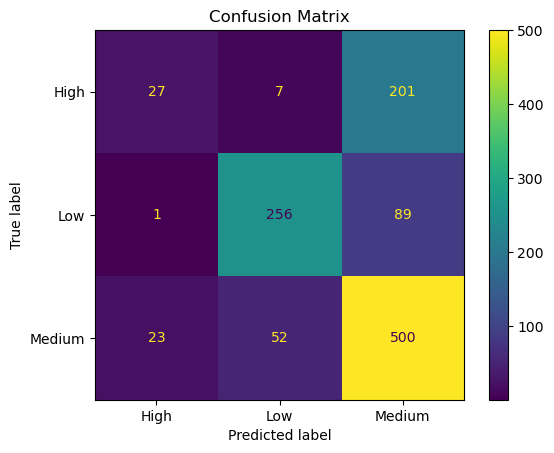

In [17]:
# Initialize the CatBoostClassifier with RMSE as the loss function
catboost_df = CatBoostClassifier(iterations=100,depth=2,random_state=2,learning_rate=0.2,verbose=10)

catboost_df.fit(X_train,y_train)

# Predict test
y_pred_catboost = catboost_df.predict(X_test)

print("Training score: {:.2f}%".format(boost_df.score(X_train,y_train)*100))
print("Test accuracy: {:.2f}%".format(boost_df.score(X_test, y_test) * 100))

# plot confusion matrix
matrix = confusion_matrix(y_test, y_pred_catboost)
display = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=catboost_df.classes_)
display.plot()
plt.title('Confusion Matrix')
plt.show()

The Catboost confusion matrix produced 500 accurate medium predictions, which was the best overall, but ahd similar predictions to all other models across the board.

In [18]:
# create a dataframe of feature importances and their corresponding column names
importances_catboost_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': catboost_df.feature_importances_})
importances_catboost_df = importances_catboost_df.sort_values('Importance', ascending=False).reset_index(drop=True)

# display the table
print(importances_catboost_df)

                    Feature  Importance
0     employee_residence_US   20.825236
1       experience_level_SE   13.949240
2       experience_level_EN   12.070884
3       salary_currency_USD   11.559459
4    job_title_Data Analyst    8.774317
..                      ...         ...
275     company_location_MD    0.000000
276     company_location_MK    0.000000
277     company_location_MT    0.000000
278     company_location_SE    0.000000
279     company_location_SG    0.000000

[280 rows x 2 columns]


Catboost showed similar features for importance, but also had a higher volume of importances in the 8-21% ranges than the other models.

## Compare the model results (model performance, feature importance, etc.)

In [19]:
# Test Error

print("*Bagging Training score: {:.2f}%".format(df_bagging.score(X_train,y_train)*100))
print("Bagging Test accuracy: {:.2f}%".format(df_bagging.score(X_test, y_test) * 100))
print("Reduced Bagging Training score: {:.2f}%".format(bagging2.score(X_train,y_train)*100))
print("*Reduced Bagging Test accuracy: {:.2f}%".format(bagging2.score(X_test, y_test) * 100))
print("RF Training score: {:.2f}%".format(df_rf.score(X_train,y_train)*100))
print("*RF Test accuracy: {:.2f}%".format(df_rf.score(X_test, y_test) * 100))
print("Boost Training score: {:.2f}%".format(boost_df.score(X_train,y_train)*100))
print("Boost Test accuracy: {:.2f}%".format(boost_df.score(X_test, y_test) * 100))
print("Gradient Training score: {:.2f}%".format(gboost_df.score(X_train,y_train)*100))
print("Gradient Test accuracy: {:.2f}%".format(gboost_df.score(X_test, y_test) * 100))
print("Catboost Training score: {:.2f}%".format(catboost_df.score(X_train,y_train)*100))
print("Catboost Test accuracy: {:.2f}%".format(catboost_df.score(X_test, y_test) * 100))

*Bagging Training score: 76.71%
Bagging Test accuracy: 68.86%
Reduced Bagging Training score: 76.61%
*Reduced Bagging Test accuracy: 68.60%
RF Training score: 76.71%
*RF Test accuracy: 68.77%
Boost Training score: 70.07%
Boost Test accuracy: 67.13%
Gradient Training score: 72.04%
Gradient Test accuracy: 67.21%
Catboost Training score: 67.13%
Catboost Test accuracy: 67.73%


Our bagging models had the best training and test scores, while random forest als oscored fairly well in testing as well.

It is worth noting that the test scores are all with 67-69%, indicating that our models all scored similarly in practice.

In [20]:
# Importance

print(importances_df_bagging)
print(importances_df_bag)
print(importances_df_rf)
print(importances_boost_df)
print(importances_gboost_df)
print(importances_catboost_df)

                    Feature  Importance
0     employee_residence_US    0.316660
1       experience_level_EN    0.042835
2    job_title_Data Analyst    0.040990
3       experience_level_SE    0.034312
4       experience_level_MI    0.029215
..                      ...         ...
275     company_location_BE    0.000000
276     salary_currency_THB    0.000000
277     salary_currency_SGD    0.000000
278     company_location_AR    0.000000
279     company_location_AS    0.000000

[280 rows x 2 columns]
                    Feature  Importance
0     employee_residence_US    0.322805
1       experience_level_EN    0.043458
2    job_title_Data Analyst    0.040740
3       experience_level_SE    0.033089
4       experience_level_MI    0.029797
..                      ...         ...
275     salary_currency_PLN    0.000000
276     salary_currency_THB    0.000000
277     company_location_AS    0.000000
278     company_location_AR    0.000000
279     company_location_AM    0.000000

[280 rows x 2 c

Across the board, US residence, and senior level experience were the most important factors. Some of this can be explained by the response variable being in US currency, and then Data Science being a more advanced scientific field would also indicate that senior level experience is important when considering the response variable of salary.

US salary currency, the data analyst title, and entry level experience were also usually among the top five factors as well.

## 7. Interpret the results

Bagging and random forest were the best performing models here, but there was not an extreme amount of variance in our results here as well.

The CatBoost model was most effective in identifying key variables in this model and showed more importance across multiple variables overall.

Ultimately, tree-based models were shown to be effective in predicting salary ranges for our dataset.

# Lab 3: Cameron Mangione (Classification)

## 1. State the question

## Note: Using a full model here did not produce visuals for SVM since it is better for binary variables, but I did show performance here for the overall classification model.

## For this lab, I included an example of a clearer hyperplane and boundary for employee residence in the US vs. Canada in addition to the full model to prove that I can produce these plots here in python.

Which classification/categorical factors have the greatest influence on salary in usd for data science positions?

# 2. Data preparation

To keep our data separate from our forest models, we will re-import our dataset and make a copy of it for our cleaning process.

In [21]:
from sklearn.svm import SVC, SVR
from ISLP.svm import plot as plot_svm
from sklearn.metrics import RocCurveDisplay, classification_report
roc_curve = RocCurveDisplay.from_estimator # shorthand

In [22]:
df2 = pd.read_csv("https://raw.githubusercontent.com/CameronMangione/Group_Project_2_DATA_5322/refs/heads/main/data/ds_salaries_clean.csv")
df2.head()

,ID,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,1,2020,EX,FT,Staff Data Analyst,15000,USD,15000,NG,0,CA,M
1,2,2020,MI,FT,Business Data Analyst,95000,USD,95000,US,0,US,M
2,3,2020,EN,FT,Data Engineer,1000000,INR,13493,IN,100,IN,L
3,4,2020,EN,FT,Data Analyst,20000,EUR,22809,PT,100,PT,M
4,5,2020,EN,FT,Data Scientist,43200,EUR,49268,DE,0,DE,S


In [23]:
clean = df2.copy()
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3191 entries, 0 to 3190
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   ID                  3191 non-null   int64 
 1   work_year           3191 non-null   int64 
 2   experience_level    3191 non-null   object
 3   employment_type     3191 non-null   object
 4   job_title           3191 non-null   object
 5   salary              3191 non-null   int64 
 6   salary_currency     3191 non-null   object
 7   salary_in_usd       3191 non-null   int64 
 8   employee_residence  3191 non-null   object
 9   remote_ratio        3191 non-null   int64 
 10  company_location    3191 non-null   object
 11  company_size        3191 non-null   object
dtypes: int64(5), object(7)
memory usage: 299.3+ KB


For SVM, we will still use a classifier for US salary, but we will use a simpler model and have two bins for low (below the mean) and high(above the mean).

In [24]:
# Create 3 categories for salaries - Low, Medium, High
clean['salary_in_usd'] = pd.cut(clean['salary_in_usd'],
                                      bins=[0, 130000, 600000],
                                      labels=[0, 1])
clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3191 entries, 0 to 3190
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   ID                  3191 non-null   int64   
 1   work_year           3191 non-null   int64   
 2   experience_level    3191 non-null   object  
 3   employment_type     3191 non-null   object  
 4   job_title           3191 non-null   object  
 5   salary              3191 non-null   int64   
 6   salary_currency     3191 non-null   object  
 7   salary_in_usd       3191 non-null   category
 8   employee_residence  3191 non-null   object  
 9   remote_ratio        3191 non-null   int64   
 10  company_location    3191 non-null   object  
 11  company_size        3191 non-null   object  
dtypes: category(1), int64(4), object(7)
memory usage: 277.6+ KB


In [25]:
# One-hot encode categorical variables
encoder = OneHotEncoder(handle_unknown='ignore')
categorical_cols = ['remote_ratio', 'company_location', 'employee_residence','experience_level','employment_type','job_title','salary_currency','company_size']
encoded_col = pd.DataFrame(encoder.fit_transform(clean[categorical_cols]).toarray())
encoded_col.columns = encoder.get_feature_names_out(categorical_cols)

# Split the Data between test and train
X_train, X_test, y_train, y_test =  train_test_split(encoded_col,
                                                 clean['salary_in_usd'],
                                                 train_size = 2035, test_size = 1156,
                                                 random_state = 2)

# reset the index of the salaries DataFrame
clean = clean.reset_index(drop=True)

## 2. Apply the support vector classifier method (explain details such as data prep & visualization, CV, parameter tuning, etc.)

### SVC (Full Model)

In [26]:
print(X_train.columns.tolist())

['remote_ratio_0', 'remote_ratio_50', 'remote_ratio_100', 'company_location_AE', 'company_location_AL', 'company_location_AM', 'company_location_AR', 'company_location_AS', 'company_location_AT', 'company_location_AU', 'company_location_BA', 'company_location_BE', 'company_location_BO', 'company_location_BR', 'company_location_BS', 'company_location_CA', 'company_location_CF', 'company_location_CH', 'company_location_CL', 'company_location_CN', 'company_location_CO', 'company_location_CR', 'company_location_CZ', 'company_location_DE', 'company_location_DK', 'company_location_DZ', 'company_location_EE', 'company_location_EG', 'company_location_ES', 'company_location_FI', 'company_location_FR', 'company_location_GB', 'company_location_GH', 'company_location_GR', 'company_location_HK', 'company_location_HN', 'company_location_HR', 'company_location_HU', 'company_location_ID', 'company_location_IE', 'company_location_IL', 'company_location_IN', 'company_location_IQ', 'company_location_IR',

There are 280 columns here which represent all of our categorical features. This will make visualizing our full model SVM extremely difficult, so we will proceed in this case to running our full model.

In [27]:
svc_model = SVC(C=0.01,kernel="linear")
svc_model.fit(X_train,y_train)

train_ct = confusion_table(y_train,svc_model.predict(X_train))
print("Training accuracy: {:.2f}%".format(svc_model.score(X_train, y_train) * 100))
print(train_ct)

y_pred_svc = svc_model.predict(X_test)

test_ct = confusion_table(y_test,y_pred_svc)
print("Test accuracy: {:.2f}%".format(svc_model.score(X_test, y_test) * 100))
print(test_ct)

# Count the number of support vectors
num_support_vectors = len(svc_model.support_)

print(f'Number of support vectors: {num_support_vectors}')

Training accuracy: 75.87%
Truth        0    1
Predicted          
0          688  410
1           81  856
Test accuracy: 74.22%
Truth        0    1
Predicted          
0          398  234
1           64  460
Number of support vectors: 1336


Overall, with an arbitrary C = 0.01, our model performs well with a 75.87% test accuracy, and a great test accuracy of 74.22%.

This model is very good, but running cross-validation should make it better.

In [28]:
kfold = skm.KFold(5, 
                  random_state=2,
                  shuffle=True)
grid = skm.GridSearchCV(svc_model,
                        {'C':[0.001,0.01,0.1,1,5,10,100]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy')
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.cv_results_[('mean_test_score')])

{'C': 1}
[0.73513514 0.73464373 0.77690418 0.78771499 0.78722359 0.78427518
 0.78525799]


Our cross validation shows that C=1 is the best model here, so we will run our SVC again with this new C value.

In [29]:
svc_best = SVC(C=1,kernel="linear")
svc_best.fit(X_train,y_train)
train_ct = confusion_table(y_train,svc_best.predict(X_train))
print("Training accuracy: {:.2f}%".format(svc_best.score(X_train, y_train) * 100))
print(train_ct)

y_pred_svc = svc_best.predict(X_test)

test_ct = confusion_table(y_test,y_pred_svc)
print("Test accuracy: {:.2f}%".format(svc_best.score(X_test, y_test) * 100))
print(test_ct)

# Count the number of support vectors
num_support_vectors = len(svc_best.support_)

print(f'Number of support vectors: {num_support_vectors}')

Training accuracy: 81.08%
Truth        0    1
Predicted          
0          884  214
1          171  766
Test accuracy: 75.87%
Truth        0    1
Predicted          
0          487  145
1          134  390
Number of support vectors: 967


Our training accuracy increased signifcantly to 81.08%, and our test accuracy increased to 75.87%, which are both excellent overall.

This plot is not very useful due to the number of feautres in our data set, and the non-binary aspects we are attempting to fit into this analysis.

However, an ROC-curve is effective for this feature heavy model since it can show us the differences in accuracy between our different fits.

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


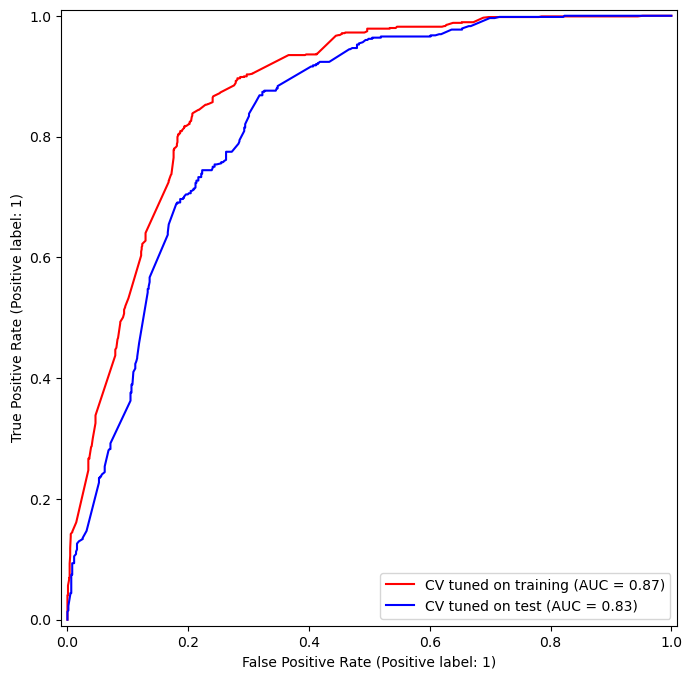

In [30]:
fig, ax = subplots(figsize=(8,8))
for (X_, y_, c, name) in zip(
     (X_train, X_test),
     (y_train, y_test),
     ('r', 'b'),
     ('CV tuned on training',
      'CV tuned on test')):
    roc_curve(svc_best,
              X_,
              y_,
              name=name,
              ax=ax,
              color=c)

Overall, our testing and training CV are pretty close with some variance around the true positive rate of 0.8 and the false positive rate of 0.3.

With this in mind, the SVC does well in predicting this dataset, although the visualization is difficult to interpret with all of these features.

An RBF kernel is also worth testing in this model due to the varied number of features and values within those features.

### SVM (Full Model)

In [31]:
svm_rbf = SVC(C=0.01,kernel="rbf", gamma=1)
svm_rbf.fit(X_train,y_train)

train_ct = confusion_table(y_train,svm_rbf.predict(X_train))
print("Training accuracy: {:.2f}%".format(svm_rbf.score(X_train, y_train) * 100))
print(train_ct)

y_pred_rbf = svm_rbf.predict(X_test)

test_ct = confusion_table(y_test,y_pred_rbf)
print("Test accuracy: {:.2f}%".format(svm_rbf.score(X_test, y_test) * 100))
print(test_ct)

# Count the number of support vectors
num_support_vectors = len(svm_rbf.support_)

print(f'Number of support vectors: {num_support_vectors}')

Training accuracy: 53.96%
Truth         0  1
Predicted         
0          1098  0
1           937  0
Test accuracy: 54.67%
Truth        0  1
Predicted        
0          632  0
1          524  0
Number of support vectors: 1914


Immediately, we see a drop in both training and test accuracy falling within the 50-60% range, as well as most of our values falling into support vectors.

Cross-Validation could help us significantly here since this might just be an issue with our initial gamma and C selections.

In [32]:
kfold = skm.KFold(5, 
                  random_state=2,
                  shuffle=True)
grid = skm.GridSearchCV(svm_rbf,
                        {'C':[0.1,1,10,100,1000],
                         'gamma':[0.5,1,2,3,4]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy');
grid.fit(X_train, y_train)
print(grid.best_params_)
print(grid.cv_results_[('mean_test_score')])

{'C': 10, 'gamma': 0.5}
[0.76117936 0.72678133 0.68353808 0.67567568 0.67567568 0.795086
 0.79017199 0.78280098 0.78280098 0.78280098 0.7970516  0.79164619
 0.78280098 0.78280098 0.78280098 0.7970516  0.79164619 0.78280098
 0.78280098 0.78280098 0.7970516  0.79164619 0.78280098 0.78280098
 0.78280098]


In [33]:
svm_best = SVC(C=10,kernel="rbf", gamma=0.5)
svm_best.fit(X_train,y_train)

train_ct = confusion_table(y_train,svm_best.predict(X_train))
print("Training accuracy: {:.2f}%".format(svm_best.score(X_train, y_train) * 100))
print(train_ct)


y_pred_rbf = svm_best.predict(X_test)

test_ct = confusion_table(y_test,y_pred_rbf)
print("Test accuracy: {:.2f}%".format(svm_best.score(X_test, y_test) * 100))
print(test_ct)

# Count the number of support vectors
num_support_vectors = len(svm_best.support_)

print(f'Number of support vectors: {num_support_vectors}')

Training accuracy: 83.88%
Truth        0    1
Predicted          
0          904  194
1          134  803
Test accuracy: 76.99%
Truth        0    1
Predicted          
0          494  138
1          128  396
Number of support vectors: 1207


Our training accuracy imporaved greatly to 83.88%, and our test accuracy also greatly improved to ~76.99%, proving to be an overall better model than the SVC we used previously.

^Raw so code can run copmletely.

While we can see much more of a boundary here, this graph is also not as useful here since we cannot see a hyperplance and the margin itself is difficult to interpret since we do not know what the exact boundar represents.

However, an ROC-curve is effective for this feature heavy model since it can show us the differences in accuracy between our different fits.

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


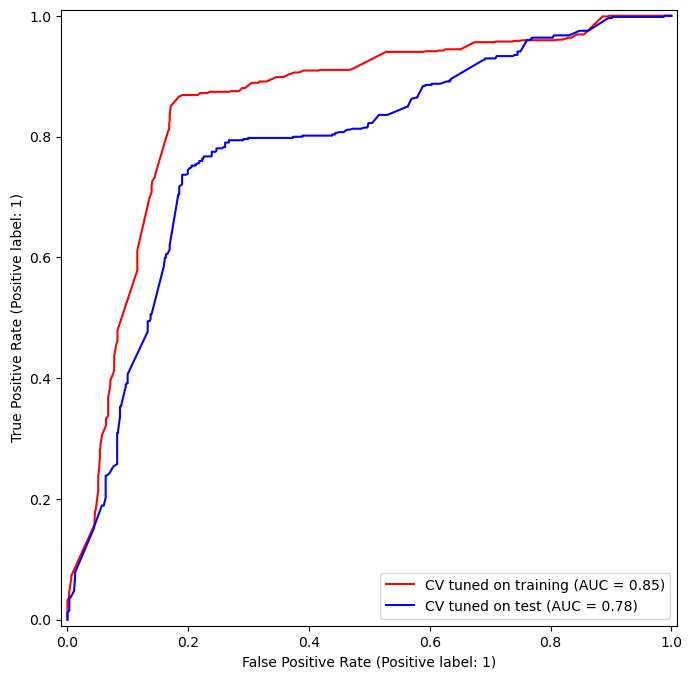

In [34]:
fig, ax = subplots(figsize=(8,8))
for (X_, y_, c, name) in zip(
     (X_train, X_test),
     (y_train, y_test),
     ('r', 'b'),
     ('CV tuned on training',
      'CV tuned on test')):
    roc_curve(svm_best,
              X_,
              y_,
              name=name,
              ax=ax,
              color=c)

This plot shows a bit more divergence compared to the SVC plot but both AUC are still high with the training having an AUC of 0.85, and the test AUC being 0.78.

### SVC (US vs. Canada)

In this section here, we will explore a more binary relationship between US and Canada Residence to show cleaner plots compared to the full model.

In [35]:
# Reducing model to US and Canada
X_train_2d = X_train[['employee_residence_CA', 'employee_residence_US']].reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)
X_test_2d = X_test[['employee_residence_CA', 'employee_residence_US']].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Train SVM on 2 features
svc_linear = SVC(C=0.01, kernel='linear')
svc_linear.fit(X_train_2d, y_train_reset)

train_ct = confusion_table(y_train_reset,svc_linear.predict(X_train_2d))
print("Training accuracy: {:.2f}%".format(svc_linear.score(X_train_2d, y_train_reset) * 100))
print(train_ct)

y_pred_2d = svc_linear.predict(X_test_2d)

test_ct = confusion_table(y_test_reset,y_pred_2d)
print("Test accuracy: {:.2f}%".format(svc_linear.score(X_test_2d, y_test_reset) * 100))
print(test_ct)

# Count the number of support vectors
num_support_vectors = len(svc_linear.support_)

print(f'Number of support vectors: {num_support_vectors}')

Training accuracy: 69.63%
Truth        0    1
Predicted          
0          551  547
1           71  866
Test accuracy: 68.69%
Truth        0    1
Predicted          
0          307  325
1           37  487
Number of support vectors: 1636


\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


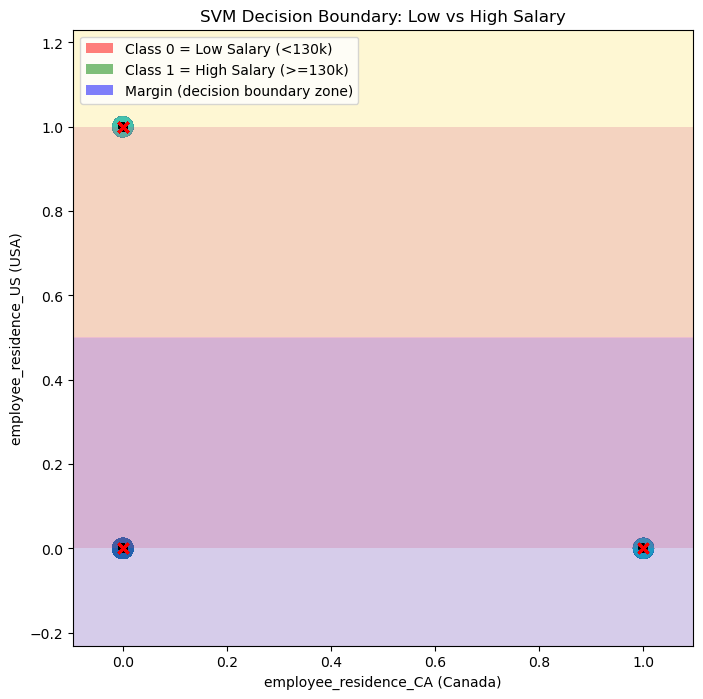

In [36]:
# Reducing model to US and Canada
X_train_2d = X_train[['employee_residence_CA', 'employee_residence_US']].reset_index(drop=True)
y_train_reset = y_train.reset_index(drop=True)

# Train SVM on 2 features
svc_linear = SVC(C=0.01, kernel='linear')
svc_linear.fit(X_train_2d, y_train_reset)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_2d, y_train_reset, svc_linear, ax=ax)

# Add legend and labels
ax.set_xlabel("employee_residence_CA (Canada)")
ax.set_ylabel("employee_residence_US (USA)")
ax.set_title("SVM Decision Boundary: Low vs High Salary")

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.5, label='Class 0 = Low Salary (<130k)'),
    Patch(facecolor='green', alpha=0.5, label='Class 1 = High Salary (>=130k)'),
    Patch(facecolor='blue', alpha=0.5, label='Margin (decision boundary zone)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


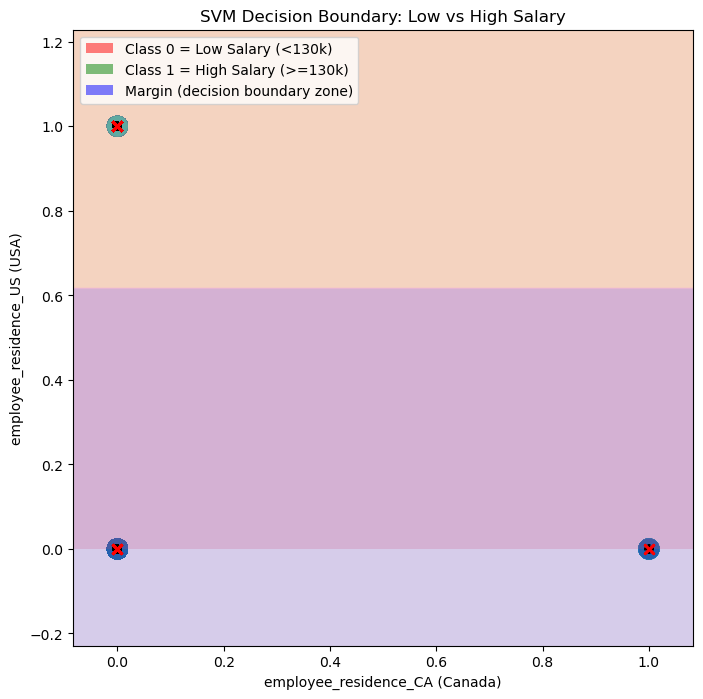

In [37]:
# Reducing model to US and Canada
X_test_2d = X_test[['employee_residence_CA', 'employee_residence_US']].reset_index(drop=True)
y_test_reset = y_test.reset_index(drop=True)

# Train SVM on 2 features
svc_linear = SVC(C=0.01, kernel='linear')
svc_linear.fit(X_test_2d, y_test_reset)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_test_2d, y_test_reset, svc_linear, ax=ax)

# Add legend and labels
ax.set_xlabel("employee_residence_CA (Canada)")
ax.set_ylabel("employee_residence_US (USA)")
ax.set_title("SVM Decision Boundary: Low vs High Salary")

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.5, label='Class 0 = Low Salary (<130k)'),
    Patch(facecolor='green', alpha=0.5, label='Class 1 = High Salary (>=130k)'),
    Patch(facecolor='blue', alpha=0.5, label='Margin (decision boundary zone)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

All three points in these models are support vectors as they are on the boundaries in these cases.

Both the test and training cases fall in the range of 68-70%, which are both slightly lower than our full models, but more interpretable.

We can use cross-validation to improve this model here.

In [38]:
kfold = skm.KFold(5, 
                  random_state=2,
                  shuffle=True)
grid = skm.GridSearchCV(svc_linear,
                        {'C':[0.1,1,10,100,1000]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy');
grid.fit(X_train_2d, y_train_reset)
print(grid.best_params_)
print(grid.cv_results_[('mean_test_score')])

{'C': 0.1}
[0.6963145 0.6963145 0.6963145 0.6963145 0.6963145]


The C value here is the same across all parameters so we will not use a new C since they all produce the same values.

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


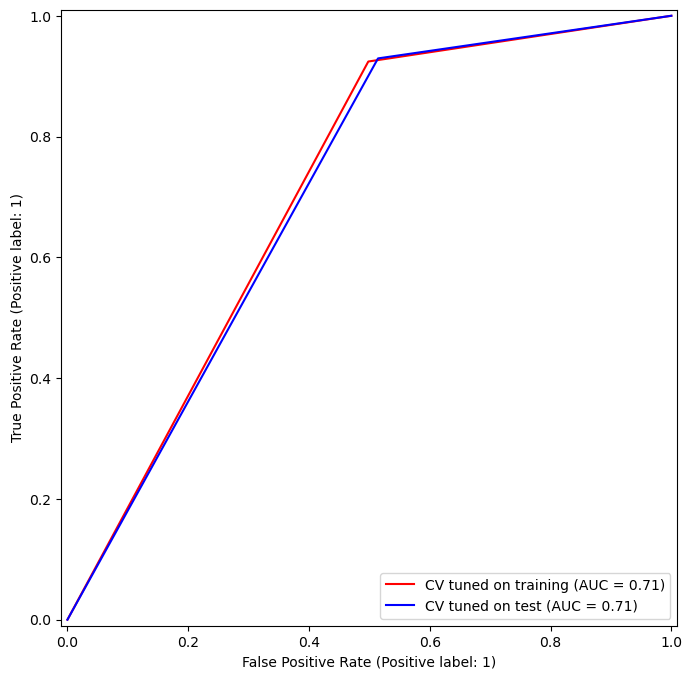

In [39]:
fig, ax = subplots(figsize=(8,8))
for (X_, y_, c, name) in zip(
     (X_train_2d, X_test_2d),
     (y_train_reset, y_test_reset),
     ('r', 'b'),
     ('CV tuned on training',
      'CV tuned on test')):
    roc_curve(svc_linear,
              X_,
              y_,
              name=name,
              ax=ax,
              color=c)

Our training and test lines here are nearly identical and have AUC values of 0.71 and 0.72 for training and testing respectively, and both are lower than the values in our full model.

### SVM US vs. Canada

Again, we want to see if an SVM and rbf works better for our data here.

In [40]:
# Train SVM on 2 features
svm_linear = SVC(C=0.01, kernel='rbf', gamma=0.1)
svm_linear.fit(X_train_2d, y_train_reset)

train_ct = confusion_table(y_train_reset,svm_linear.predict(X_train_2d))
print("Training accuracy: {:.2f}%".format(svm_linear.score(X_train_2d, y_train_reset) * 100))
print(train_ct)

y_pred_2d = svm_linear.predict(X_test_2d)

test_ct = confusion_table(y_test_reset,y_pred_2d)
print("Test accuracy: {:.2f}%".format(svm_linear.score(X_test_2d, y_test_reset) * 100))
print(test_ct)

# Count the number of support vectors
num_support_vectors = len(svm_linear.support_)

print(f'Number of support vectors: {num_support_vectors}')

Training accuracy: 53.96%
Truth         0  1
Predicted         
0          1098  0
1           937  0
Test accuracy: 54.67%
Truth        0  1
Predicted        
0          632  0
1          524  0
Number of support vectors: 1875


Similar to our full model, these training and test scores are pretty low around 53-55%.

Cross Validation may be able to improve this.

In [41]:
kfold = skm.KFold(5, 
                  random_state=2,
                  shuffle=True)
grid = skm.GridSearchCV(svm_linear,
                        {'C':[0.1,1,10,100,1000],
                         'gamma':[0.5,1,2,3,4]},
                        refit=True,
                        cv=kfold,
                        scoring='accuracy');
grid.fit(X_train_2d, y_train_reset)
print(grid.best_params_)
print(grid.cv_results_[('mean_test_score')])

{'C': 0.1, 'gamma': 0.5}
[0.6963145 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145
 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145
 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145 0.6963145
 0.6963145 0.6963145 0.6963145 0.6963145]


We can now test these values in our new model.

In [42]:
# Train SVM on 2 features
svm_linear2 = SVC(C=0.1, kernel='rbf', gamma=0.5)
svm_linear2.fit(X_train_2d, y_train_reset)

train_ct = confusion_table(y_train_reset,svm_linear2.predict(X_train_2d))
print("Training accuracy: {:.2f}%".format(svm_linear2.score(X_train_2d, y_train_reset) * 100))
print(train_ct)

y_pred_2d = svm_linear2.predict(X_test_2d)

test_ct = confusion_table(y_test_reset,y_pred_2d)
print("Test accuracy: {:.2f}%".format(svm_linear2.score(X_test_2d, y_test_reset) * 100))
print(test_ct)

# Count the number of support vectors
num_support_vectors = len(svm_linear2.support_)

print(f'Number of support vectors: {num_support_vectors}')

Training accuracy: 69.63%
Truth        0    1
Predicted          
0          551  547
1           71  866
Test accuracy: 68.69%
Truth        0    1
Predicted          
0          307  325
1           37  487
Number of support vectors: 1291


This shows overall improvement and identical results for what we had in the regular SVC model.

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


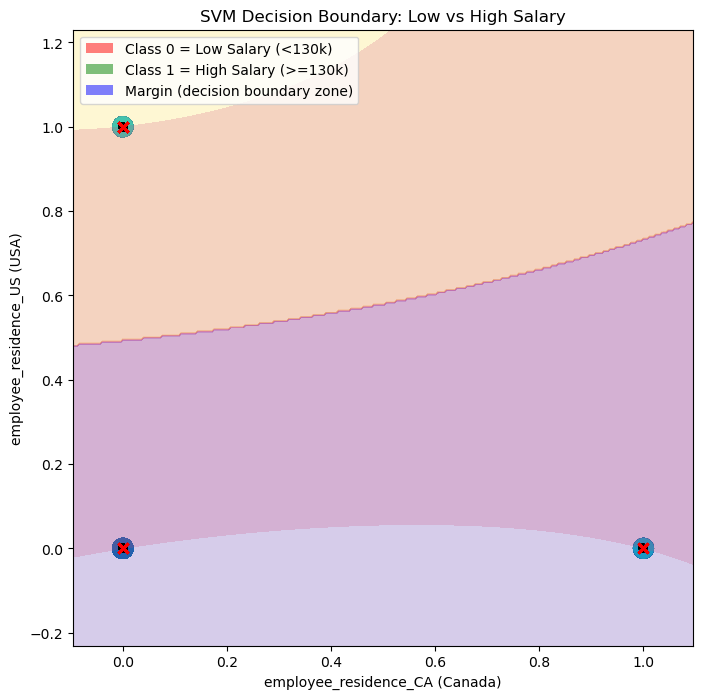

In [43]:
# Train SVM on 2 features
svm_linear = SVC(C=0.1, kernel='rbf', gamma=0.5)
svm_linear.fit(X_train_2d, y_train_reset)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
plot_svm(X_train_2d, y_train_reset, svm_linear, ax=ax)

# Add legend and labels
ax.set_xlabel("employee_residence_CA (Canada)")
ax.set_ylabel("employee_residence_US (USA)")
ax.set_title("SVM Decision Boundary: Low vs High Salary")

# Add custom legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', alpha=0.5, label='Class 0 = Low Salary (<130k)'),
    Patch(facecolor='green', alpha=0.5, label='Class 1 = High Salary (>=130k)'),
    Patch(facecolor='blue', alpha=0.5, label='Margin (decision boundary zone)')
]
ax.legend(handles=legend_elements, loc='upper left')
plt.show()

These plots show more of a curved boundary as compared to the regular svc model.

\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
\\?\C:\Users\2TBSSD\AppData\Roaming\jupyterlab-desktop\envs\env_2\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


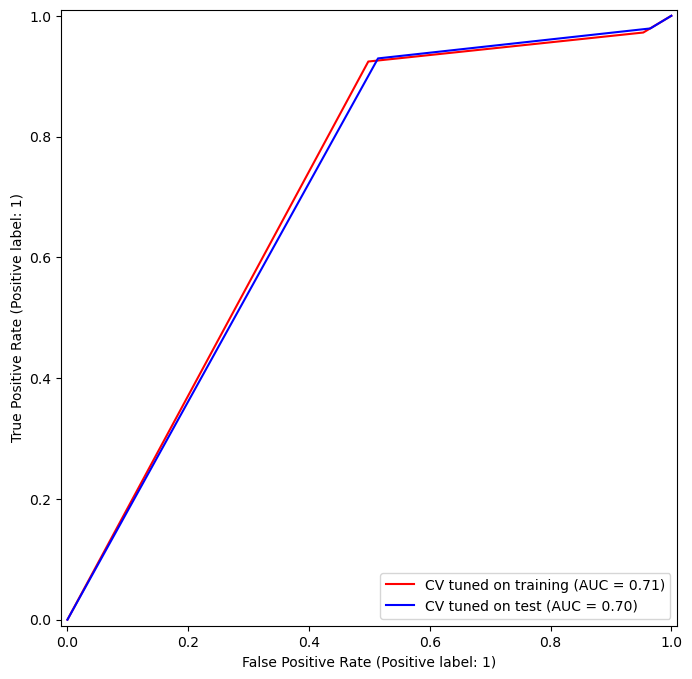

In [44]:
fig, ax = subplots(figsize=(8,8))
for (X_, y_, c, name) in zip(
     (X_train_2d, X_test_2d),
     (y_train_reset, y_test_reset),
     ('r', 'b'),
     ('CV tuned on training',
      'CV tuned on test')):
    roc_curve(svm_linear,
              X_,
              y_,
              name=name,
              ax=ax,
              color=c)

The ROC-curves are nearly identical to eachother with the main difference being that the test AUC is now 0.7.

## 3. Check and analyze the model performance

In [45]:
# Test Error

print("SVC Training accuracy: {:.2f}%".format(svc_model.score(X_train, y_train) * 100))
print("SVC Test accuracy: {:.2f}%".format(svc_model.score(X_test, y_test) * 100))
print("Best SVC Training accuracy: {:.2f}%".format(svc_best.score(X_train, y_train) * 100))
print("Best SVC Test accuracy: {:.2f}%".format(svc_best.score(X_test, y_test) * 100))
print("SVM RBF Training accuracy: {:.2f}%".format(svm_rbf.score(X_train, y_train) * 100))
print("SVM RBF Test accuracy: {:.2f}%".format(svm_rbf.score(X_test, y_test) * 100))
print("*Best SVM RBF Training accuracy: {:.2f}%".format(svm_best.score(X_train, y_train) * 100))
print("*Best SVM RBF Test accuracy: {:.2f}%".format(svm_best.score(X_test, y_test) * 100))
print("Single SVC Training accuracy: {:.2f}%".format(svc_linear.score(X_train_2d, y_train_reset) * 100))
print("Single SVC Test accuracy: {:.2f}%".format(svc_linear.score(X_test_2d, y_test_reset) * 100))
print("Single SVM Training accuracy: {:.2f}%".format(svm_linear.score(X_train_2d, y_train_reset) * 100))
print("Single SVM Test accuracy: {:.2f}%".format(svm_linear.score(X_test_2d, y_test_reset) * 100))
print("Best Single SVM Training accuracy: {:.2f}%".format(svm_linear2.score(X_train_2d, y_train_reset) * 100))
print("Best Single SVM Test accuracy: {:.2f}%".format(svm_linear2.score(X_test_2d, y_test_reset) * 100))

SVC Training accuracy: 75.87%
SVC Test accuracy: 74.22%
Best SVC Training accuracy: 81.08%
Best SVC Test accuracy: 75.87%
SVM RBF Training accuracy: 53.96%
SVM RBF Test accuracy: 54.67%
*Best SVM RBF Training accuracy: 83.88%
*Best SVM RBF Test accuracy: 76.99%
Single SVC Training accuracy: 69.63%
Single SVC Test accuracy: 68.69%
Single SVM Training accuracy: 69.63%
Single SVM Test accuracy: 68.69%
Best Single SVM Training accuracy: 69.63%
Best Single SVM Test accuracy: 68.69%


Overall, the full model, cross-validatated svm-rbf model performed the best on training score and in testing score.

The singular model saw identical results across the board, and the initial svm RBF model performed the worst.

Most of these these models proved effective in analyzing our datasets, but cross-validation made these models more effective overall in our results.

## Explain how this compares with tree-based models

In terms of both training accuraccy and testing accuracy, we saw a 7% increase overall utilizing our best SVM model versus tree models with our full model.

We noticed that there was variance with these performances across these models, but that cross-validation truly helped us get the best performance on our best models.